# EXPERIMENT – 4
## Composite Transformations Using Matrix Representation

**Name:** Ojas B A  
**USN:** 1RVU23CSE321  
**Course:** Computer Graphics and Virtual Reality

### Aim
To implement composite 2D transformations using homogeneous coordinates and matrix representation.

### Transformation Sequence
Scaling → Rotation → Translation

The equivalent composite matrix is:

**Composite = T × R × S**


In [1]:
%%writefile experiment4.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <iomanip>
using namespace std;

struct Point {
    double x, y;
};

using Matrix = vector<vector<double>>;

Matrix multiply(const Matrix& A, const Matrix& B) {
    Matrix C(3, vector<double>(3, 0.0));
    for (int i = 0; i < 3; i++)
        for (int j = 0; j < 3; j++)
            for (int k = 0; k < 3; k++)
                C[i][j] += A[i][k] * B[k][j];
    return C;
}

Point applyTransform(const Matrix& M, const Point& p) {
    return {
        M[0][0] * p.x + M[0][1] * p.y + M[0][2],
        M[1][0] * p.x + M[1][1] * p.y + M[1][2]
    };
}

vector<Point> transformShape(const vector<Point>& shape, const Matrix& M) {
    vector<Point> result;
    for (const auto& p : shape)
        result.push_back(applyTransform(M, p));
    return result;
}

void printShape(const string& tag, const vector<Point>& shape) {
    for (const auto& p : shape)
        cout << tag << " " << fixed << setprecision(2)
             << p.x << " " << p.y << "\n";
}

int main() {
    vector<Point> original = {
        {-40, -30},
        { 40, -30},
        {  0,  50}
    };

    double angle = 30.0 * acos(-1.0) / 180.0;

    Matrix S = {
        {1.4, 0.0, 0.0},
        {0.0, 1.4, 0.0},
        {0.0, 0.0, 1.0}
    };

    Matrix R = {
        { cos(angle), -sin(angle), 0.0},
        { sin(angle),  cos(angle), 0.0},
        { 0.0,         0.0,        1.0}
    };

    Matrix T = {
        {1.0, 0.0, 60.0},
        {0.0, 1.0, 40.0},
        {0.0, 0.0, 1.0}
    };

    // Sequential transformation: Scale -> Rotate -> Translate
    vector<Point> scaled = transformShape(original, S);
    vector<Point> rotated = transformShape(scaled, R);
    vector<Point> sequential = transformShape(rotated, T);

    // Composite matrix for the same order: T * R * S
    Matrix composite = multiply(T, multiply(R, S));
    vector<Point> compositeResult = transformShape(original, composite);

    printShape("ORIGINAL", original);
    printShape("SCALED", scaled);
    printShape("ROTATED", rotated);
    printShape("SEQUENTIAL", sequential);
    printShape("COMPOSITE", compositeResult);

    cout << "MATRIX\n";
    for (int i = 0; i < 3; i++) {
        cout << fixed << setprecision(4)
             << composite[i][0] << " "
             << composite[i][1] << " "
             << composite[i][2] << "\n";
    }

    return 0;
}


Writing experiment4.cpp


In [2]:
!g++ experiment4.cpp -o experiment4
output = !./experiment4

shapes = {
    "ORIGINAL": [],
    "SCALED": [],
    "ROTATED": [],
    "SEQUENTIAL": [],
    "COMPOSITE": []
}

matrix = []
reading_matrix = False

for line in output:
    if line == "MATRIX":
        reading_matrix = True
        continue

    if reading_matrix:
        matrix.append([float(v) for v in line.split()])
    else:
        tag, x, y = line.split()
        shapes[tag].append((float(x), float(y)))

print("Composite matrix (T × R × S):")
for row in matrix:
    print(row)

max_difference = max(
    abs(a - b)
    for p1, p2 in zip(shapes["SEQUENTIAL"], shapes["COMPOSITE"])
    for a, b in zip(p1, p2)
)

print("\nSequential result :", shapes["SEQUENTIAL"])
print("Composite result  :", shapes["COMPOSITE"])
print("Maximum difference:", max_difference)
print("Verified: composite matrix gives the same final coordinates as sequential transformations.")


Composite matrix (T × R × S):
[1.2124, -0.7, 60.0]
[0.7, 1.2124, 40.0]
[0.0, 0.0, 1.0]

Sequential result : [(32.5, -24.37), (129.5, 31.63), (25.0, 100.62)]
Composite result  : [(32.5, -24.37), (129.5, 31.63), (25.0, 100.62)]
Maximum difference: 0.0
Verified: composite matrix gives the same final coordinates as sequential transformations.


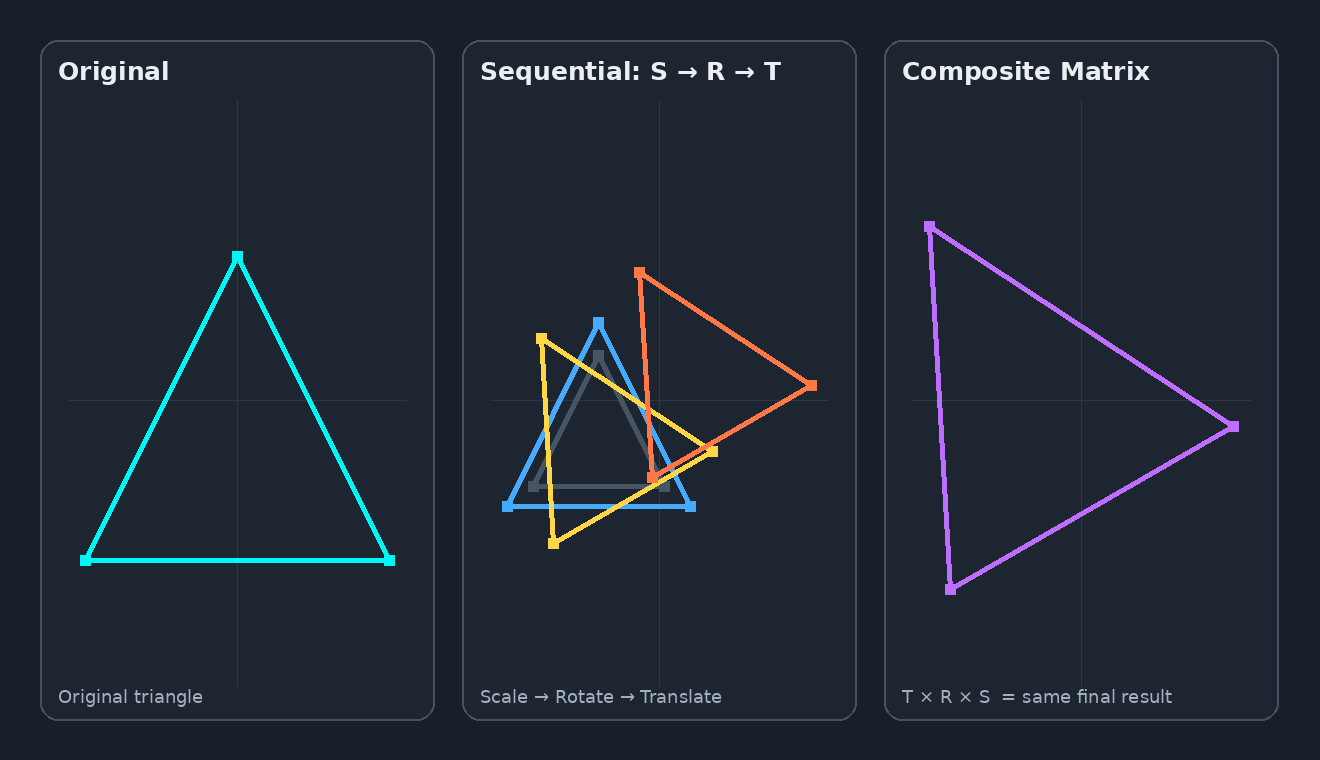

Saved as experiment4_composite_transformations.png


In [3]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

W, H = 1320, 760
bg = (23, 31, 40)
panel = (28, 37, 48)
border = (70, 82, 96)
text = (235, 239, 244)
muted = (165, 176, 188)

img = Image.new("RGB", (W, H), bg)
draw = ImageDraw.Draw(img)

try:
    title_font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 25)
    body_font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 18)
except:
    title_font = None
    body_font = None

margin = 40
gap = 28
panel_w = (W - 2 * margin - 2 * gap) // 3
panel_h = H - 2 * margin

items = [
    ("Original", ["ORIGINAL"], [(0, 245, 245)]),
    ("Sequential: S → R → T", ["ORIGINAL", "SCALED", "ROTATED", "SEQUENTIAL"],
     [(70, 85, 100), (70, 170, 255), (255, 215, 70), (255, 120, 70)]),
    ("Composite Matrix", ["COMPOSITE"], [(190, 110, 255)])
]

def bounds_for(keys):
    pts = [p for key in keys for p in shapes[key]]
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    return min(xs), max(xs), min(ys), max(ys)

def map_points(points, x0, y0, x1, y1, keys):
    xmin, xmax, ymin, ymax = bounds_for(keys)
    pad = 45
    usable_w = (x1 - x0) - 2 * pad
    usable_h = (y1 - y0) - 95
    span_x = max(xmax - xmin, 1)
    span_y = max(ymax - ymin, 1)
    scale = min(usable_w / span_x, usable_h / span_y)
    cx_data = (xmin + xmax) / 2
    cy_data = (ymin + ymax) / 2
    cx = (x0 + x1) / 2
    cy = (y0 + y1) / 2 + 28

    result = []
    for x, y in points:
        px = cx + (x - cx_data) * scale
        py = cy - (y - cy_data) * scale
        result.append((px, py))
    return result

for i, (label, keys, colors) in enumerate(items):
    x0 = margin + i * (panel_w + gap)
    y0 = margin
    x1 = x0 + panel_w
    y1 = y0 + panel_h

    draw.rounded_rectangle((x0, y0, x1, y1), radius=18, fill=panel, outline=border, width=2)
    draw.text((x0 + 18, y0 + 16), label, fill=text, font=title_font)

    # subtle reference axes
    midx = (x0 + x1) / 2
    midy = (y0 + y1) / 2 + 20
    draw.line((x0 + 28, midy, x1 - 28, midy), fill=(45, 55, 68), width=1)
    draw.line((midx, y0 + 60, midx, y1 - 34), fill=(45, 55, 68), width=1)

    for key, color in zip(keys, colors):
        pts = map_points(shapes[key], x0, y0, x1, y1, keys)
        draw.line(pts + [pts[0]], fill=color, width=5)
        for px, py in pts:
            draw.rectangle((px - 5, py - 5, px + 5, py + 5), fill=color)

    if i == 1:
        draw.text((x0 + 18, y1 - 34), "Scale → Rotate → Translate", fill=muted, font=body_font)
    elif i == 2:
        draw.text((x0 + 18, y1 - 34), "T × R × S  = same final result", fill=muted, font=body_font)
    else:
        draw.text((x0 + 18, y1 - 34), "Original triangle", fill=muted, font=body_font)

img.save("experiment4_composite_transformations.png")
display(img)
print("Saved as experiment4_composite_transformations.png")


### Result
Composite transformations were implemented successfully using matrix multiplication. The composite matrix produced the same final coordinates as applying scaling, rotation, and translation sequentially.
